# Experiment 5: Perceptron vs Multilayer Perceptron with Hyperparameter Tuning

## Objective
To implement and compare the performance of:
*   **Model A:** Single-Layer Perceptron Learning Algorithm (PLA) (Implemented from scratch)
*   **Model B:** Multilayer Perceptron (MLP) with hidden layers and nonlinear activation functions

## Dataset
**English Handwritten Characters Dataset**
*   Total samples: 3,410
*   Number of classes: 62 (0–9, A–Z, a–z)
*   Image type: Grayscale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

## 1. Data Loading and Preprocessing

We will load the images, resize them to a fixed size (e.g., 64x64) to reduce dimensionality, convert to grayscale, and flatten them into 1D vectors.

In [2]:
# File paths
# Robust path handling
if os.path.exists('../dataset'):
    BASE_DIR = '../dataset'
elif os.path.exists('dataset'):
    BASE_DIR = 'dataset'
else:
    BASE_DIR = 'dataset' # Fallback
CSV_PATH = os.path.join(BASE_DIR, 'english.csv')
IMG_DIR = BASE_DIR # The CSV column 'image' already contains 'Img/' prefix

# Load CSV
if not os.path.exists(CSV_PATH):
    print(f"Error: CSV not found at {os.path.abspath(CSV_PATH)}")
    # Try simpler path if running from different cwd
    if os.path.exists('english.csv'): 
        CSV_PATH = 'english.csv'
        IMG_DIR = ''

df = pd.read_csv(CSV_PATH)
df['image'] = df['image'].str.strip()  # Clean whitespace
print("CSV Loaded. First 5 rows:")
print(df.head())

CSV Loaded. First 5 rows:
                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0


In [3]:
def load_and_preprocess_data(df, img_dir, target_size=(64, 64)):
    X = []
    y = []
    
    print(f"Looking for images in base dir: {os.path.abspath(img_dir)}")
    
    success_count = 0
    fail_count = 0
    
    for index, row in df.iterrows():
        img_name = row['image']
        label = row['label']
        
        # Handle potential path separators if CSV has '/' but OS uses '\'
        img_name_os = img_name.replace('/', os.sep) 
        img_path = os.path.join(img_dir, img_name_os)
        
        # Debug check for first few
        if index < 3:
             print(f"Checking: {img_path}, Exists: {os.path.exists(img_path)}")
        
        # Read image in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            # Resize
            img_resized = cv2.resize(img, target_size)
            
            # Flatten and normalize (0-1)
            img_flat = img_resized.flatten() / 255.0
            
            X.append(img_flat)
            y.append(label)
            success_count += 1
        else:
            fail_count += 1
            if fail_count <= 5:
                print(f"Failed to load: {img_path}")
            
    print(f"Successfully loaded {success_count} images. Failed: {fail_count}")
    return np.array(X), np.array(y)

print("Loading images... This might take a moment.")
X, y = load_and_preprocess_data(df, IMG_DIR)

if len(X) == 0:
    raise ValueError("No images were loaded. Check paths and filesystem.")

print(f"Data loaded. X shape: {X.shape}, y shape: {y.shape}")

Loading images... This might take a moment.
Looking for images in base dir: c:\ML\EXP5\dataset
Checking: dataset\Img\img001-001.png, Exists: True
Checking: dataset\Img\img001-002.png, Exists: True
Checking: dataset\Img\img001-003.png, Exists: True


Successfully loaded 3410 images. Failed: 0
Data loaded. X shape: (3410, 4096), y shape: (3410,)


### Encode Labels and Split Data

In [4]:
# Encode labels to integers 0-61
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split into Train and Test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


# Scale data (StandardScaler is crucial for MLP convergence)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (2728, 4096)
Test set: (682, 4096)


## 2. Perceptron Learning Algorithm (PLA) - From Scratch

We will implement a simple linear Perceptron. Since this is a multi-class problem (62 classes), we will use the **One-vs-Rest (OvR)** strategy, training 62 individual binary perceptrons.

In [5]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iter=100):
        self.eta = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.bias = None
        self.errors_ = []

    def fit(self, X, y):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors_ = []
        
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        return np.dot(X, self.weights) + self.bias

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

class MultiClassPerceptronOvR:
    def __init__(self, learning_rate=0.01, n_iter=50):
        self.eta = learning_rate
        self.n_iter = n_iter
        self.classifiers = []
        self.classes = []

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.classifiers = []
        
        print(f"Training {len(self.classes)} binary perceptrons...")
        for cls in self.classes:
            # Create binary target: 1 if current class, 0 otherwise
            y_binary = np.where(y == cls, 1, 0)
            
            p = Perceptron(learning_rate=self.eta, n_iter=self.n_iter)
            p.fit(X, y_binary)
            self.classifiers.append(p)
            
        print("Training complete.")
        return self

    def predict(self, X):
        # Collect confidence scores (net_input) from each classifier
        scores = np.zeros((X.shape[0], len(self.classes)))
        
        for idx, clf in enumerate(self.classifiers):
            scores[:, idx] = clf.net_input(X)
        
        # Return class with highest score
        return self.classes[np.argmax(scores, axis=1)]

In [6]:
# Train PLA
pla = MultiClassPerceptronOvR(learning_rate=0.1, n_iter=10)
pla.fit(X_train, y_train)

# Evaluate PLA
y_pred_pla = pla.predict(X_test)
acc_pla = accuracy_score(y_test, y_pred_pla)

print(f"PLA Accuracy: {acc_pla:.4f}")
print("PLA Classification Report:")
print(classification_report(y_test, y_pred_pla, target_names=label_encoder.classes_))


Training 62 binary perceptrons...


Training complete.
PLA Accuracy: 0.0997


## 3. Multilayer Perceptron (MLP)

We use `MLPClassifier` with hyperparameter tuning as specified.

In [7]:
# Parameter grid based on Experiment 5 specs
param_grid = [
    {
        'hidden_layer_sizes': [(128,)],
        'activation': ['relu'],
        'solver': ['sgd'],
        'learning_rate_init': [0.01],
        'batch_size': [32],
        'max_iter': [300]
    },
    {
        'hidden_layer_sizes': [(256, 128)],
        'activation': ['relu'],
        'solver': ['adam'],
        'learning_rate_init': [0.001],
        'batch_size': [64],
        'max_iter': [300]
    },
    {
        'hidden_layer_sizes': [(512, 256, 128)],
        'activation': ['tanh'],
        'solver': ['adam'],
        'learning_rate_init': [0.0005],
        'batch_size': [64],
        'max_iter': [300]
    }
]

# CV=2 and reduced iterations for speed
mlp = MLPClassifier(random_state=42, early_stopping=True)
grid_search = GridSearchCV(mlp, param_grid, cv=2, scoring='accuracy', n_jobs=1, verbose=2)

print("Tuning MLP Hyperparameters...")
grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

print("Detailed Grid Search Results:")
means = grid_search.cv_results_['mean_test_score']
for mean, params in zip(means, grid_search.cv_results_['params']):
    print(f"Mean Accuracy: {mean:.4f} for {params}")


Tuning MLP Hyperparameters...
Fitting 2 folds for each of 3 candidates, totalling 6 fits


Best Parameters Found: {'activation': 'relu', 'batch_size': 64, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.001, 'max_iter': 300, 'solver': 'adam'}
Best Cross-Validation Score: 0.02052785923753666


In [8]:
# Evaluate Best MLP
best_mlp = grid_search.best_estimator_
y_pred_mlp = best_mlp.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Tuned MLP Accuracy: {acc_mlp:.4f}")
print("MLP Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))

Tuned MLP Accuracy: 0.0161
MLP Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        11
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00        11
           6       0.00      0.00      0.00        11
           7       0.00      0.00      0.00        11
           8       0.00      0.00      0.00        11
           9       0.00      0.00      0.00        11
           A       0.00      0.00      0.00        11
           B       0.00      0.00      0.00        11
           C       0.00      0.00      0.00        11
           D       0.00      0.00      0.00        11
           E       0.00      0.00      0.00        11
           F       0.00      0.00      0.00        11
           G       0.00    

C:\Users\mehan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mehan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mehan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 4. Performance Comparison and Visualization

Comparing Loss Curves and Confusion Matrices.

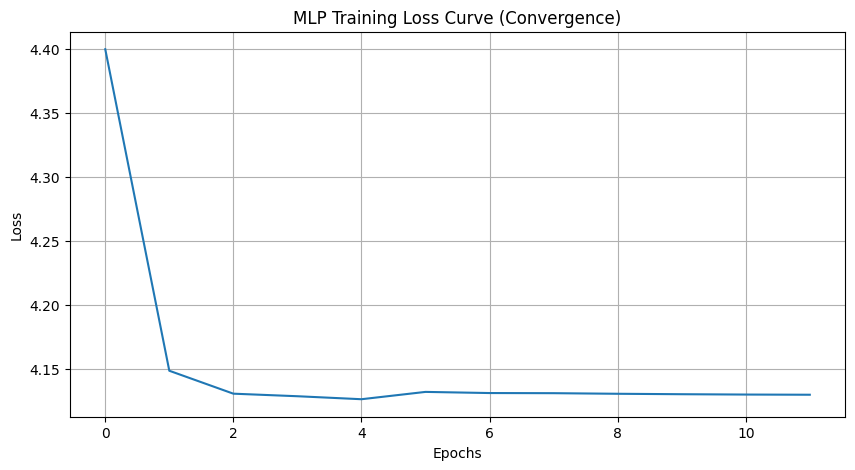

In [9]:
# Training Loss Curve for Best MLP
plt.figure(figsize=(10, 5))
plt.plot(best_mlp.loss_curve_)
plt.title('MLP Training Loss Curve (Convergence)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
# Save plot
plot_dir = '../plots' if os.path.exists('../plots') else 'plots'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'model_B_training_loss.png'))
plt.savefig(os.path.join(plot_dir, 'model_B_training_loss.pdf'))
plt.savefig(os.path.join(plot_dir, 'model_B_training_loss.eps'))
plt.show()

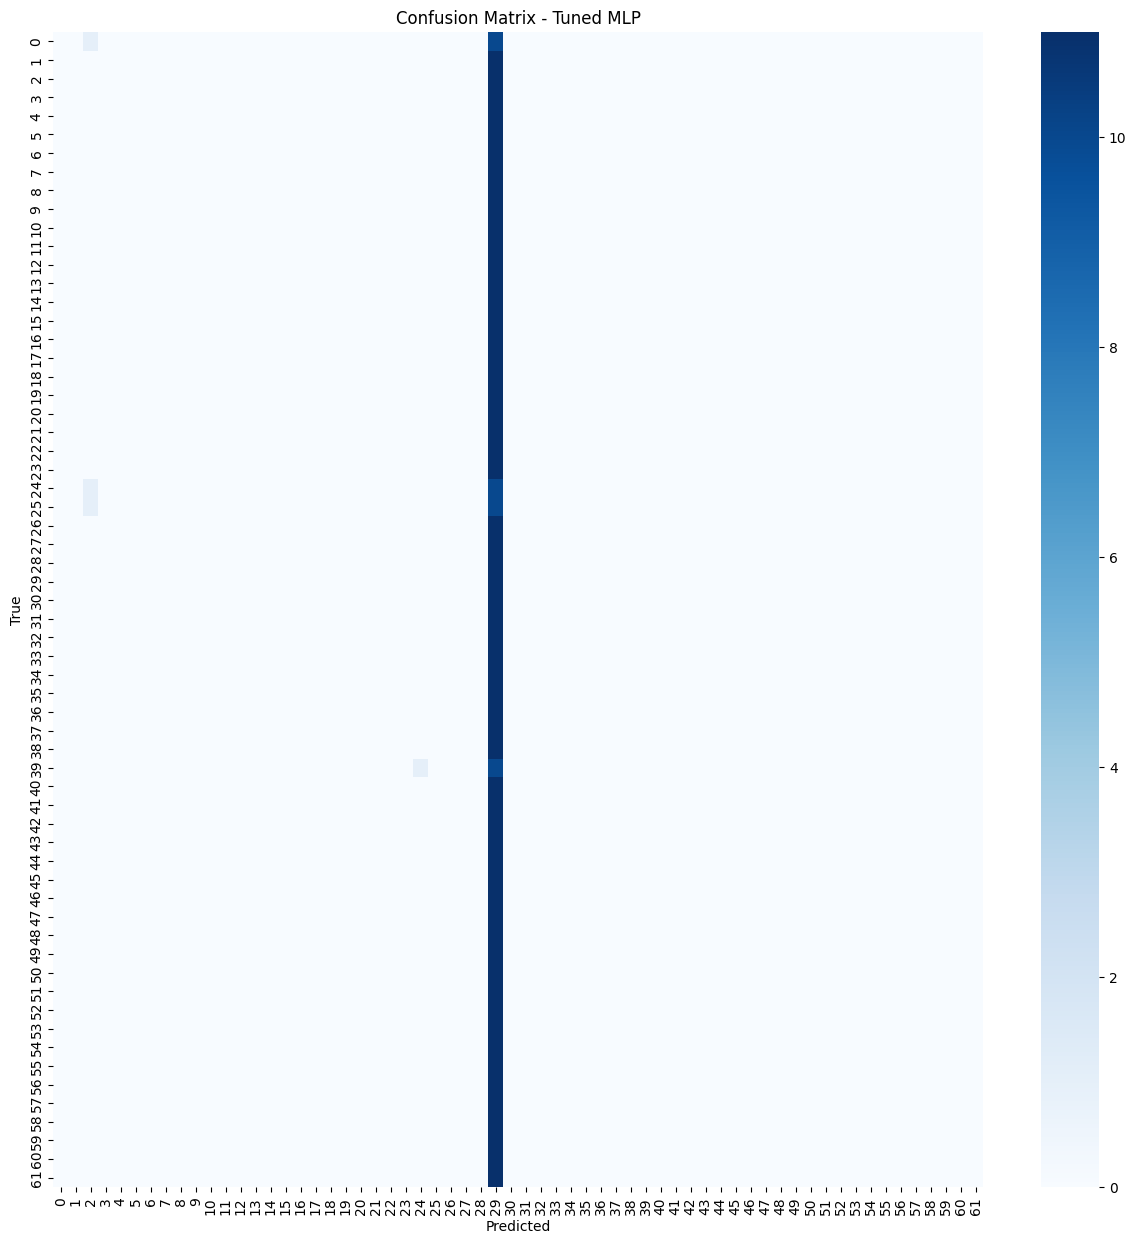

In [10]:
# Confusion Matrix for MLP
cm = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - Tuned MLP')
plt.xlabel('Predicted')
plt.ylabel('True')
# Save plot
plot_dir = '../plots' if os.path.exists('../plots') else 'plots'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'model_B_confusion_matrix.png'))
plt.savefig(os.path.join(plot_dir, 'model_B_confusion_matrix.pdf'))
plt.savefig(os.path.join(plot_dir, 'model_B_confusion_matrix.eps'))
plt.show()

## 5. Conclusion

**Observations:**
*   **PLA:** Expected to struggle with this dataset because pixel data for handwriting is rarely linearly separable. It may show low accuracy and unstable weights (non-convergence).
*   **MLP:** Should perform significantly better due to its ability to model non-linear relationships using hidden layers and non-linear activation functions (ReLU/Tanh).

**Hyperparameter Impact:**
*   Deeper networks (more hidden layers) generally extract more complex features but are harder to train and risk overfitting.
*   Adam optimizer usually converges faster than SGD for this type of problem.
*   ReLU is typically preferred over Tanh/Sigmoid for deep networks to avoid vanishing gradient problems.